In [1]:
#Libraries
!pip install matplotlib rouge_score transformers sentencepiece

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=44455efcfce5fc0afcb53e037bbdd55ebf0f5b4893bcd705af8b18bcc9af0115
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [2]:
#Imports
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

In [3]:
#Config
max_vocab = 50000
max_article_len = 400
max_summary_len = 50
embedding_dim = 128
latent_dim = 128
epochs = 20
batch_size = 64

In [4]:
#Load dataset
train_df = pd.read_csv('train.csv')
val_df   = pd.read_csv('validation.csv')
test_df  = pd.read_csv('test.csv')

In [5]:
#Cleaning text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

train_articles = train_df['article'].astype(str).apply(clean_text)
train_summaries = train_df['highlights'].astype(str).apply(clean_text)

val_articles = val_df['article'].astype(str).apply(clean_text)
val_summaries = val_df['highlights'].astype(str).apply(clean_text)

test_articles = test_df['article'].astype(str).apply(clean_text)
test_summaries = test_df['highlights'].astype(str).apply(clean_text)

train_summaries = 'startseq ' + train_summaries + ' endseq'
val_summaries   = 'startseq ' + val_summaries + ' endseq'
test_summaries  = 'startseq ' + test_summaries + ' endseq'

In [6]:
#Limiting dataset size
N_TRAIN = 30000
N_VAL   = 3000
N_TEST  = 3000

train_articles = train_articles[:N_TRAIN]
train_summaries = train_summaries[:N_TRAIN]

val_articles = val_articles[:N_VAL]
val_summaries = val_summaries[:N_VAL]

test_articles = test_articles[:N_TEST]
test_summaries = test_summaries[:N_TEST]

In [7]:
#Tokenization
article_tokenizer = Tokenizer(num_words=max_vocab, oov_token='<unk>')
summary_tokenizer = Tokenizer(num_words=max_vocab, oov_token='<unk>')

article_tokenizer.fit_on_texts(train_articles)
summary_tokenizer.fit_on_texts(train_summaries)

def tokenize_and_pad(tokenizer, texts, max_len):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=max_len, padding='post')

X_train = tokenize_and_pad(article_tokenizer, train_articles, max_article_len)
X_val   = tokenize_and_pad(article_tokenizer, val_articles, max_article_len)
X_test  = tokenize_and_pad(article_tokenizer, test_articles, max_article_len)

y_train = tokenize_and_pad(summary_tokenizer, train_summaries, max_summary_len)
y_val   = tokenize_and_pad(summary_tokenizer, val_summaries, max_summary_len)
y_test  = tokenize_and_pad(summary_tokenizer, test_summaries, max_summary_len)

decoder_target_train = np.expand_dims(y_train[:, 1], axis=-1)
decoder_target_val   = np.expand_dims(y_val[:, 1], axis=-1)

In [8]:
#Bahdanau attention layer
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)

    def call(self, enc_out, dec_hidden):
        dec_hidden = tf.expand_dims(dec_hidden, 1)
        score = self.V(tf.nn.tanh(self.W1(enc_out) + self.W2(dec_hidden)))
        weights = tf.nn.softmax(score, axis=1)
        context = weights * enc_out
        return tf.reduce_sum(context, axis=1)

In [9]:
#Luong attention layer
class LuongAttention(tf.keras.layers.Layer):
    def call(self, enc_out, dec_hidden):
        dec_hidden = tf.expand_dims(dec_hidden, 2)
        score = tf.matmul(enc_out, dec_hidden)
        weights = tf.nn.softmax(score, axis=1)
        context = weights * enc_out
        return tf.reduce_sum(context, axis=1)

In [14]:
#Model building
def build_model(attention_type):
    enc_inputs = Input(shape=(max_article_len,))
    enc_emb = Embedding(max_vocab, embedding_dim)(enc_inputs)
    enc_out, enc_h, enc_c = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True)(enc_emb)

    dec_inputs = Input(shape=(max_summary_len,))
    dec_emb = Embedding(max_vocab, embedding_dim)(dec_inputs)
    _, dec_h, _ = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True)(dec_emb, initial_state=[enc_h, enc_c])

    if attention_type == 'bahdanau':
        context = BahdanauAttention(latent_dim)(enc_out, dec_h)
    else:
        context = LuongAttention()(enc_out, dec_h)

    concat = tf.keras.layers.concatenate([context, dec_h])
    outputs = Dense(max_vocab, activation='softmax')(concat)

    model = Model([enc_inputs, dec_inputs], outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
    return model

In [15]:
#Early stopping to avoid overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=19,
    restore_best_weights=True
)

In [16]:
#Training model(Bahdanau)
bahdanau_model = build_model('bahdanau')
bahdanau_history = bahdanau_model.fit(
    [X_train, y_train], decoder_target_train,
    validation_data=([X_val, y_val], decoder_target_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - loss: 9.1409 - val_loss: 8.0885
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 7.6643 - val_loss: 8.1342
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 7.3482 - val_loss: 8.3399
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 7.0602 - val_loss: 8.6214
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 6.7723 - val_loss: 8.9883
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 6.4742 - val_loss: 9.1743
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 6.0579 - val_loss: 9.5411
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 5.6148 - val_loss: 9.9311
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 5.1383 - val_loss: 10.2077
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 4.6190 - val_loss: 10.3865
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - loss: 4.2565 - val_loss: 10.4197
Epoch 12/20
469/469 ━━━━━━━

In [17]:
#Training model(Luong)
luong_model = build_model('luong')
luong_history = luong_model.fit(
    [X_train, y_train], decoder_target_train,
    validation_data=([X_val, y_val], decoder_target_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - loss: 9.1580 - val_loss: 8.0993
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 7.6247 - val_loss: 8.1359
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - loss: 7.2586 - val_loss: 8.4011
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 6.9106 - val_loss: 8.6584
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 6.5520 - val_loss: 9.0391
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 6.1262 - val_loss: 9.4554
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 5.6552 - val_loss: 9.9438
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 5.1355 - val_loss: 10.1525
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 4.5854 - val_loss: 10.6088
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 4.0337 - val_loss: 10.9358
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 3.4736 - val_loss: 11.3076
Epoch 12/20
469/469 ━━━━━━

In [18]:
#Model parameter table for Bahdanau
print("Bahdanau Attention Model Summary")
bahdanau_model.summary()

Bahdanau Attention Model Summary


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 400, 128)  │  6,400,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 400,      │    131,584 │ embedding_4[0][0] │
│                     │ 128), (None,      │            │                   │
│                     │ 128), (None,      │            │                   │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 50, 128)   │  6,400,000 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 50, 128), │    131,584 │ embedding_5[0][0… │
│                     │ (None, 128),      │            │ lstm_4[0][1],     │
│                     │ (None, 128)]      │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention… │ (None, 128)       │     33,153 │ lstm_4[0][0],     │
│ (BahdanauAttention) │                   │            │ lstm_5[0][1]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 256)       │          0 │ bahdanau_attenti… │
│ (Concatenate)       │                   │            │ lstm_5[0][1]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 50000)     │ 12,850,000 │ concatenate_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,838,965 (296.93 MB)

 Trainable params: 25,946,321 (98.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,892,644 (197.95 MB)

In [19]:
#Model parameter table for Luong
print("\nLuong Attention Model Summary")
luong_model.summary()


Luong Attention Model Summary


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 400, 128)  │  6,400,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ [(None, 400,      │    131,584 │ embedding_6[0][0] │
│                     │ 128), (None,      │            │                   │
│                     │ 128), (None,      │            │                   │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 50, 128)   │  6,400,000 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ [(None, 50, 128), │    131,584 │ embedding_7[0][0… │
│                     │ (None, 128),      │            │ lstm_6[0][1],     │
│                     │ (None, 128)]      │            │ lstm_6[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ luong_attention     │ (None, 128)       │          0 │ lstm_6[0][0],     │
│ (LuongAttention)    │                   │            │ lstm_7[0][1]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256)       │          0 │ luong_attention[… │
│ (Concatenate)       │                   │            │ lstm_7[0][1]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 50000)     │ 12,850,000 │ concatenate_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,739,506 (296.55 MB)

 Trainable params: 25,913,168 (98.85 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,826,338 (197.70 MB)

In [20]:
#Generating summary using token
index_to_word = summary_tokenizer.index_word
word_to_index = summary_tokenizer.word_index

def generate_summary(model, article_seq, max_len=30):
    summary = ['startseq']

    for _ in range(max_len):
        seq = summary_tokenizer.texts_to_sequences([' '.join(summary)])
        seq = pad_sequences(seq, maxlen=max_summary_len, padding='post')

        pred = model.predict([article_seq, seq], verbose=0)
        pred_id = np.argmax(pred)

        word = index_to_word.get(pred_id, None)
        if word is None or word == 'endseq':
            break

        summary.append(word)

    return ' '.join(summary[1:])

In [21]:
#Output summaries using token
def show_samples(model, n_samples=3):
    for i in range(n_samples):
        print('=' * 80)
        print(f'SAMPLE {i+1}')

        original_article = test_articles.iloc[i][:500] + '...'
        reference_summary = test_summaries.iloc[i].replace('startseq','').replace('endseq','')

        article_seq = X_test[i:i+1]
        generated_summary = generate_summary(model, article_seq)

        print('\nArticle:')
        print(original_article)

        print('\nReference Summary:')
        print(reference_summary)

        print('\nGenerated Summary:')
        print(generated_summary)
        print()

In [22]:
#Bahdanau attention result:
print('\nBahdanau Attention Results:')
show_samples(bahdanau_model, n_samples=2)


Bahdanau Attention Results:
SAMPLE 1

Article:
ever noticed how plane seats appear to be getting smaller and smaller with increasing numbers of people taking to the skies some experts are questioning if having such packed out planes is putting passengers at risk they say that the shrinking space on aeroplanes is not only uncomfortable it s putting our health and safety in danger more than squabbling over the arm rest shrinking space on planes putting our health and safety in danger this week a u s consumer advisory group set up by the depart...

Reference Summary:
 experts question if packed out planes are putting passengers at risk u s consumer advisory group says minimum space must be stipulated safety tests conducted on planes with more leg room than airlines offer  

Generated Summary:
the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the

SAMPLE 2

Article:
a drunk teenage boy had to be rescued by security after ju

In [23]:
#Luong attention result:
print('\nLuong Attention Results:')
show_samples(luong_model, n_samples=2)


Luong Attention Results:
SAMPLE 1

Article:
ever noticed how plane seats appear to be getting smaller and smaller with increasing numbers of people taking to the skies some experts are questioning if having such packed out planes is putting passengers at risk they say that the shrinking space on aeroplanes is not only uncomfortable it s putting our health and safety in danger more than squabbling over the arm rest shrinking space on planes putting our health and safety in danger this week a u s consumer advisory group set up by the depart...

Reference Summary:
 experts question if packed out planes are putting passengers at risk u s consumer advisory group says minimum space must be stipulated safety tests conducted on planes with more leg room than airlines offer  

Generated Summary:
the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the

SAMPLE 2

Article:
a drunk teenage boy had to be rescued by security after jumpi

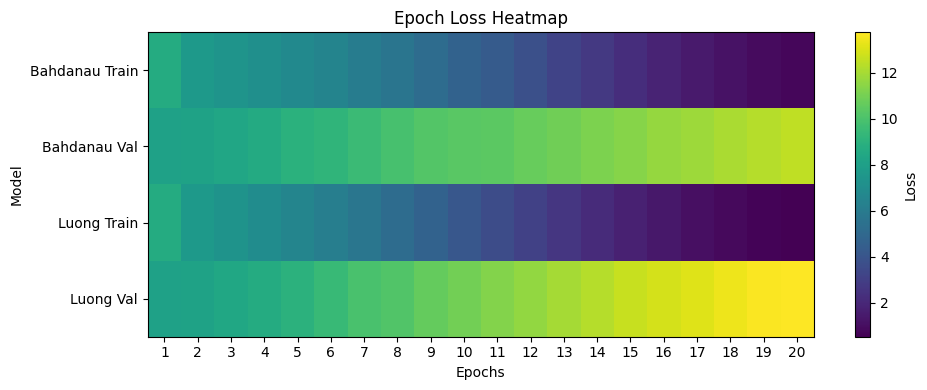

In [24]:
#Heatmap of EPOCHS(Loss)

import numpy as np
import matplotlib.pyplot as plt

bah_train = bahdanau_history.history['loss']
bah_val   = bahdanau_history.history['val_loss']
lu_train  = luong_history.history['loss']
lu_val    = luong_history.history['val_loss']

heatmap_data = np.array([
    bah_train,
    bah_val,
    lu_train,
    lu_val
])

labels = [
    'Bahdanau Train',
    'Bahdanau Val',
    'Luong Train',
    'Luong Val'
]

epochs_range = np.arange(1, len(bah_train) + 1)

plt.figure(figsize=(10, 4))
plt.imshow(heatmap_data, aspect='auto', cmap='viridis')

plt.yticks(range(len(labels)), labels)
plt.xticks(range(len(epochs_range)), epochs_range)
plt.xlabel('Epochs')
plt.ylabel('Model')
plt.title('Epoch Loss Heatmap')
plt.colorbar(label='Loss')
plt.tight_layout()
plt.show()


In [25]:
#ROUGE evaluation
from rouge_score import rouge_scorer
scorer = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=True)

def compute_rouge(model, n=100):
    scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
    for i in range(n):
        pred = model.predict([X_test[i:i+1], y_test[i:i+1]], verbose=0)
        pred_id = np.argmax(pred)
        pred_text = summary_tokenizer.sequences_to_texts([[pred_id]])[0]
        ref_text = summary_tokenizer.sequences_to_texts([y_test[i]])[0]
        s = scorer.score(ref_text, pred_text)
        for k in scores:
            scores[k].append(s[k].fmeasure)
    return {k: np.mean(v) for k,v in scores.items()}

bahdanau_rouge = compute_rouge(bahdanau_model)
luong_rouge = compute_rouge(luong_model)

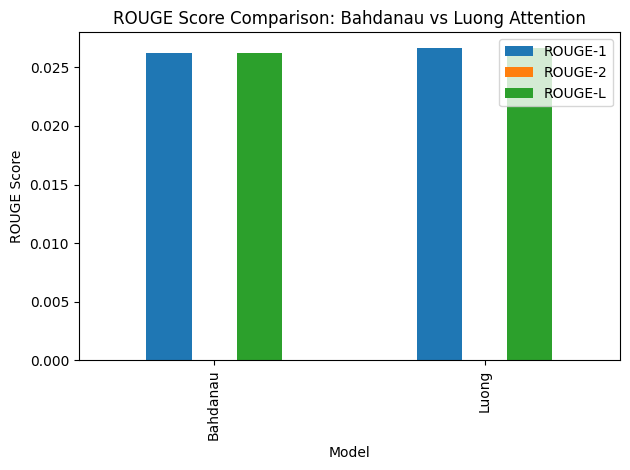

In [26]:
#Rouge comparison graph
rouge_comparison = pd.DataFrame({
    'Model': ['Bahdanau', 'Luong'],
    'ROUGE-1': [
        bahdanau_rouge['rouge1'],
        luong_rouge['rouge1']
    ],
    'ROUGE-2': [
        bahdanau_rouge['rouge2'],
        luong_rouge['rouge2']
    ],
    'ROUGE-L': [
        bahdanau_rouge['rougeL'],
        luong_rouge['rougeL']
    ]
})

rouge_comparison.set_index('Model').plot(kind='bar')
plt.xlabel('Model')
plt.ylabel('ROUGE Score')
plt.title('ROUGE Score Comparison: Bahdanau vs Luong Attention')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

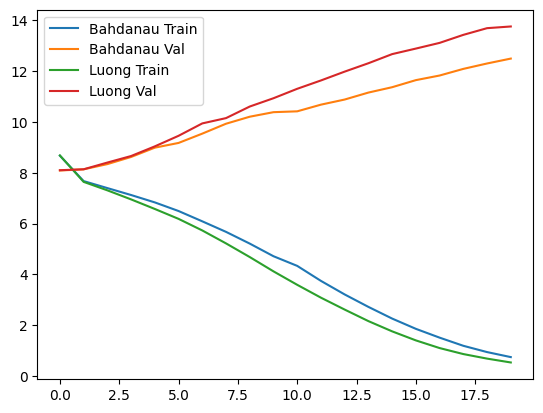

      Model   ROUGE-1  ROUGE-2   ROUGE-L
0  Bahdanau  0.026275      0.0  0.026275
1     Luong  0.026667      0.0  0.026667


In [27]:
#Plotting graphs
plt.figure()
plt.plot(bahdanau_history.history['loss'], label='Bahdanau Train')
plt.plot(bahdanau_history.history['val_loss'], label='Bahdanau Val')
plt.plot(luong_history.history['loss'], label='Luong Train')
plt.plot(luong_history.history['val_loss'], label='Luong Val')
plt.legend()
plt.show()

comparison = pd.DataFrame({
    'Model': ['Bahdanau', 'Luong'],
    'ROUGE-1': [bahdanau_rouge['rouge1'], luong_rouge['rouge1']],
    'ROUGE-2': [bahdanau_rouge['rouge2'], luong_rouge['rouge2']],
    'ROUGE-L': [bahdanau_rouge['rougeL'], luong_rouge['rougeL']]
})
print(comparison)

In [28]:
#Loading T5 model
from transformers import T5Tokenizer, T5ForConditionalGeneration

t5_tokenizer = T5Tokenizer.from_pretrained("t5-small")
t5_model = T5ForConditionalGeneration.from_pretrained("t5-small")

def t5_summarize(text, max_len=150):
    text = "summarize: " + text
    inputs = t5_tokenizer.encode(
        text, return_tensors="pt",
        truncation=True, max_length=512
    )
    summary_ids = t5_model.generate(
        inputs,
        max_length=max_len,
        min_length=40,
        num_beams=4,
        length_penalty=2.0,
        early_stopping=True
    )
    return t5_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [29]:
#Output summaries using T5
print("="*80)
print("Article:")
print(test_articles.iloc[0][:600])

print("\nT5 Generated summary:")
print(t5_summarize(test_articles.iloc[0]))

def show_t5_samples(n_samples=3):
    for i in range(n_samples):
        print("=" * 100)
        print(f"SAMPLE {i+1}")

        print("\nArticle:")
        print(test_articles.iloc[i][:600], "...")

        print("\nReference summary:")
        print(test_summaries.iloc[i].replace('startseq','').replace('endseq',''))

        print("\nT5 Generated summary:")
        print(t5_summarize(test_articles.iloc[i]))
        print()

show_t5_samples(3)


Article:
ever noticed how plane seats appear to be getting smaller and smaller with increasing numbers of people taking to the skies some experts are questioning if having such packed out planes is putting passengers at risk they say that the shrinking space on aeroplanes is not only uncomfortable it s putting our health and safety in danger more than squabbling over the arm rest shrinking space on planes putting our health and safety in danger this week a u s consumer advisory group set up by the department of transportation said at a public hearing that while the government is happy to set standards 

T5 Generated summary:
u.s consumer advisory group says shrinking space on planes is putting our health and safety in danger more than squabbling over the arm rest shrinking space on planes. faa use planes with a inch pitch a standard which on some airlines has decreased many economy seats on united airlines have inches of room. united airlines has inches of space gulf air economy seats 